# Regional Bias

In [12]:
%load_ext autoreload
%autoreload 2

In [13]:
import os
import warnings
import cf_xarray as cfxr
import dask
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import regionmask
import xarray as xr
import xesmf as xe
from dask.distributed import Client
from evaltools import obs
from evaltools.obs import eobs_mapping
from evaltools.utils import short_iid
from tools import (
    check_equal_period,
    create_cordex_grid,
    fix_360_longitudes,
    height_temperature_correction,
    load_obs,
    mask_invalid,
    open_datasets,
    regional_means,
    regrid_dsets,
    seasonal_mean,
    standardize_unit,
    var_dic,
    variable_mapping,
    plot_regional_biases,
)

dask.config.set(scheduler="single-threaded")

In [14]:
client = Client(dashboard_address="localhost:8787", threads_per_worker=1)
client

/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/conda_envs/evaltools/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43883 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:43883/status,
Dashboard: http://127.0.0.1:43883/status,Workers: 16
Total threads: 16,Total memory: 125.79 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38021,Workers: 0
Dashboard: http://127.0.0.1:43883/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44925,Total threads: 1
Dashboard: http://127.0.0.1:43021/status,Memory: 7.86 GiB
Nanny: tcp://127.0.0.1:44697,


In [15]:
from tools import open_datasets
from evaltools.source import xarray_open_kwargs

# creates chunksizes about 100MB
xarray_open_kwargs['chunks'] = {'time': 160}

In [16]:
# Parameter papermill
index = "tas"
frequency = "mon"
domain = "EUR-11"
regridding = "bilinear"
periods = [slice("1989", "2008"), slice("1991", "2020")]
reference_regions = "PRUDENCE"

In [17]:
save_results_path = os.path.abspath(
    os.path.join(os.getcwd(), "..", "intermediate-results")
)
save_figure_path = os.path.abspath(os.path.join(os.getcwd(), "..", "plots"))

In [18]:
variable = var_dic[index]["variable"]

In [19]:
eur_colors = pd.read_csv("eurocordex_models.csv")

In [20]:
if reference_regions == "PRUDENCE":
    regions = regionmask.defined_regions.prudence
elif reference_regions == "AR6":
    regions = regionmask.defined_regions.ar6.all

In [21]:
rotated_grid = create_cordex_grid("EUR-11")  # No matter CMIP5 or CMIP6

## E-OBS is used as the reference dataset for all the analysis
It is used to calculate bias not only respect to CORDEX, but also in comparison wit other reanalyses and observational dataset, to assess the uncertaintly of the observational dataset

In [22]:
ref_seasmean_periods = {}
for period in periods:
    # load, regrid and calculate seasonal means
    eobs_var = [key for key, value in eobs_mapping.items() if value == variable][0]
    eobs = obs.eobs(variables=eobs_var, 
                    version="v31.0e", source="local", add_mask=False).sel(time=slice("1989", "2020"))# select all the period
    eobs = mask_invalid(eobs, vars=eobs_var, threshold=0.001)
    eobs = eobs.rename({eobs_var: variable})
    eobs = standardize_unit(eobs, variable)
    eobs = fix_360_longitudes(eobs, lonname="longitude", reindex = True)
    # eobs = load_eobs(add_mask=False, to_cf=False, variable = variable)
    # unmapped_to_nan, see https://github.com/pangeo-data/xESMF/issues/56
    regridder = xe.Regridder(
        eobs, rotated_grid, method=regridding, unmapped_to_nan=True
    )
    ref_on_rotated = regridder(eobs)
    if not check_equal_period(ref_on_rotated, period):
        print(f"Temporal coverage of dataset does not match with {period}")
    ref_seasmean = seasonal_mean(ref_on_rotated[variable].sel(time=period)).compute()
    ref_seasmean_periods[f"{period.start}-{period.stop}"] = ref_seasmean

Convert celsius to kelvin
Convert celsius to kelvin


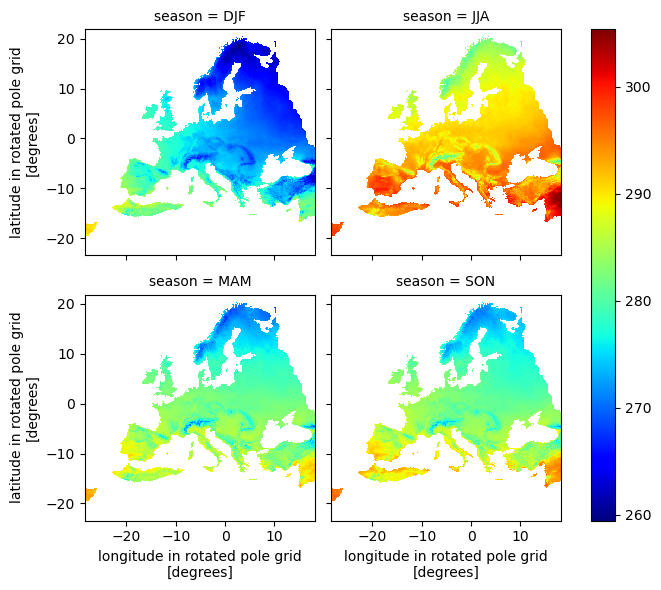

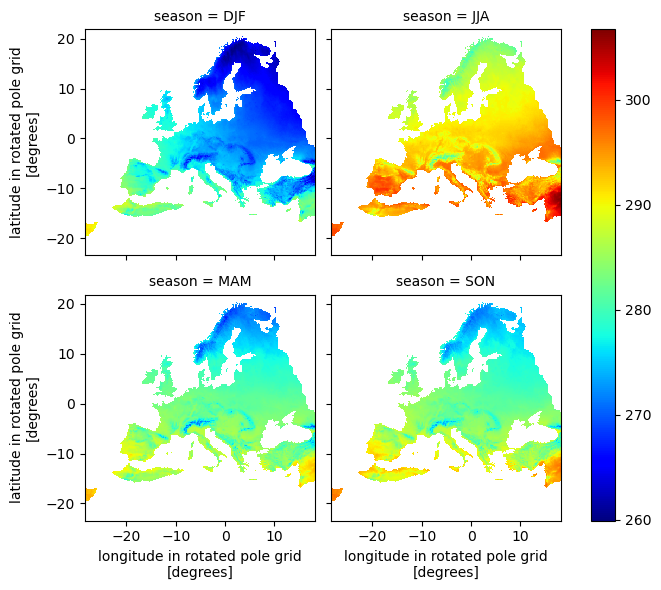

In [23]:
for period in periods:
    ref_seasmean_periods[f"{period.start}-{period.stop}"].plot(
        col="season", col_wrap=2, cmap="jet"
    )

## CERRA and ERA5

merging era5 with orog
merging era5 with sftlf
merging cerra with orog
merging cerra with sftlf


/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/conda_envs/evaltools/lib/python3.10/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 9.89 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/conda_envs/evaltools/lib/python3.10/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 9.89 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/conda_envs/evaltools/lib/python3.10/site-pa

merging era5 with orog
merging era5 with sftlf
merging cerra with orog
merging cerra with sftlf


/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/conda_envs/evaltools/lib/python3.10/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 9.89 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/conda_envs/evaltools/lib/python3.10/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 9.89 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/conda_envs/evaltools/lib/python3.10/site-pa

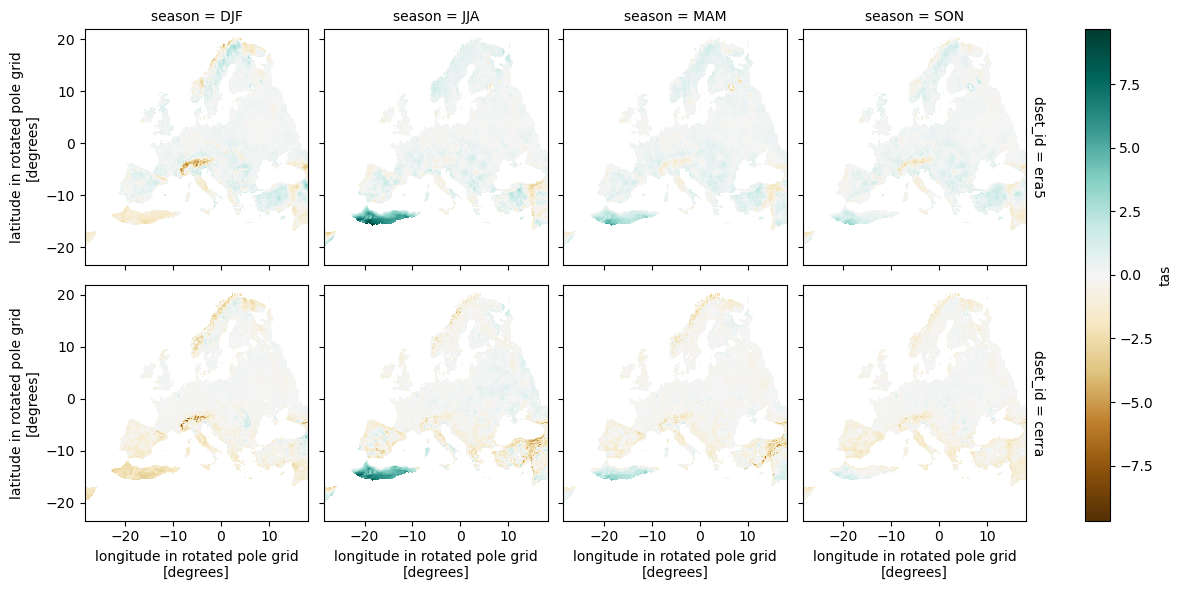

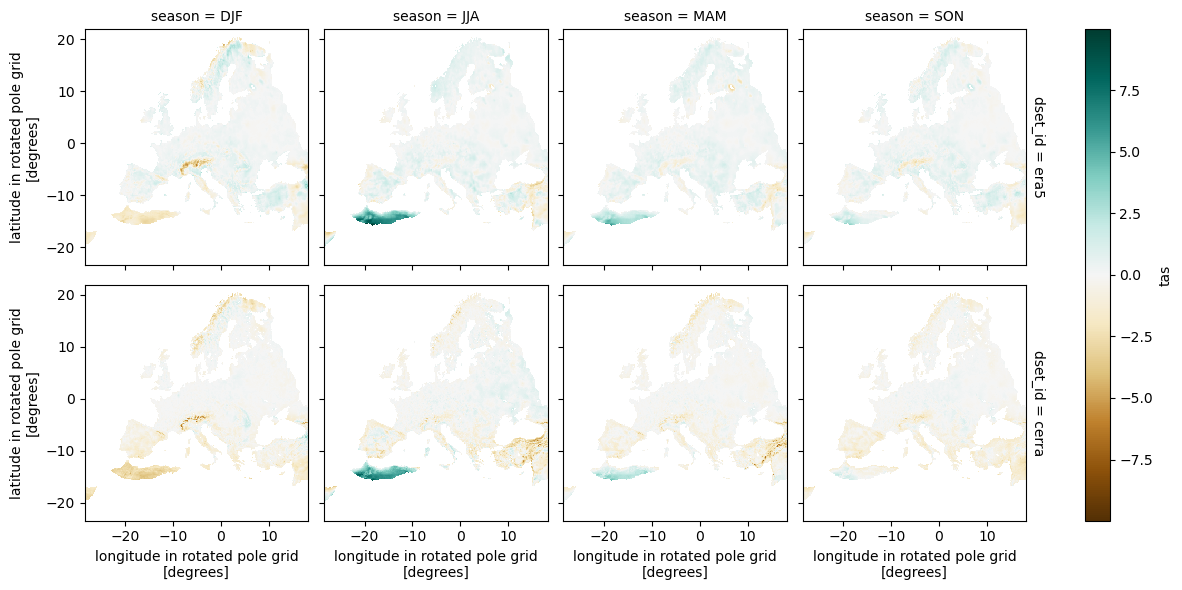

In [24]:
for period in periods:

    # Load eobs (CERRA and ERA5)
    dsets = {}
    for dset in var_dic[variable]["datasets"]:
        if dset in ["era5", "cerra", "cerra-land"]:
            ds = load_obs(variable, dset, frequency = 'mon', add_fx=True, mask=True)
            ds = fix_360_longitudes(ds, lonname="longitude", reindex = False)
        elif dset in ["rocio-ibeb"]:
            ds = load_obs('pcp', dset, frequency = 'day', add_fx=False, mask=False)
            ds = fix_360_longitudes(ds, lonname="lon", reindex = False)
            
        ds = ds.sel(time=period).compute()
        if not variable_mapping[dset][variable] == variable:
            ds = ds.rename_vars({variable_mapping[dset][variable]: variable})
        ds = standardize_unit(ds, variable)
        dsets[dset] = ds

    # Check temporal coverage
    for dset in dsets.keys():
        if not check_equal_period(dsets[dset], period):
            print(f"Temporal coverage of {dset} does not match with {period}")

    # Regrid
    for dset, ds in dsets.items():
        regridder = xe.Regridder(
            ds, rotated_grid, method=regridding, unmapped_to_nan=True
        )
        dsets[dset] = regridder(ds)

    if variable == "tas":
        for dset in dsets:
            h_c = height_temperature_correction(
                dsets[dset].orog, ref_on_rotated.elevation
            )
            dsets[dset]["tas"] = dsets[dset].tas - h_c.fillna(0)

    # Calculate seasonal_mean bias respect to the reference dataset
    ref_seasmean = ref_seasmean_periods[f"{period.start}-{period.stop}"]
    if var_dic[variable]["diff"] == "abs":
        diffs = {
            dset_id: seasonal_mean(ds[[variable]].sel(time=period)).compute()
            - (ref_seasmean)
            for dset_id, ds in dsets.items()
            if variable in ds.variables
        }
    elif var_dic[variable]["diff"] == "rel":
        diffs = {
            dset_id: 100
            * (
                seasonal_mean(ds[[variable]].sel(time=period)).compute()
                - (ref_seasmean)
            )
            / (ref_seasmean)
            for dset_id, ds in dsets.items()
            if variable in ds.variables
        }
    obs_seasonal_bias = xr.concat(
        list(diffs.values()),
        dim=xr.DataArray(
            list(map(lambda x: x, diffs.keys())),
            dims="dset_id",
        ),
        compat="override",
        coords="minimal",
    )
    # Delete cell with high relative differences (arid areas for precipitation)
    obs_seasonal_bias[variable] = obs_seasonal_bias[variable].where(
        (obs_seasonal_bias[variable] <= 1000) & (obs_seasonal_bias[variable] >= -1000)
    )
    # Plot
    obs_seasonal_bias[variable].plot(row="dset_id", col="season", cmap="BrBG")
    # Calculate regional means
    obs_regions = regional_means(
        obs_seasonal_bias, regions, aggr=var_dic[index]["aggr"]
    )
    # Save results
    obs_regions.to_netcdf(
        f"{save_results_path}/{index}_obs_{reference_regions}_{period.start}-{period.stop}.nc"
    )

## CMIP6 and CMIP5

In [25]:
CMIP_dic = {
    "CMIP6": "ERA5",
    "CMIP5": "ERAINT",
}

Opening catalog from https://euro-cordex.s3.eu-central-1.amazonaws.com/catalog/CORDEX-CMIP6-JSC.json
Found 18 source ids for variables ['tas']: ['RACMO23E', 'ICON-CLM-202407-1-1', 'GCOAST-AHOIB1-1', 'CCLM6-0-1', 'CCLM6-0-1-URB', 'HCLIM43-ALADIN', 'ROAM-NBS', 'HadREM3-GA7-05', 'REMO2020-2-2-iMOVE-LUC', 'REMO2020-2-2-MR2', 'REMO2020-2-2-TEB', 'REMO2020-2-2', 'REMO2020-2-2-iMOVE', 'WRF451Q', 'CCLM6-0-1-URB-ESG', 'CNRM-ALADIN64E1', 'RegCM5-0', 'ALARO1-SFX']

--> The keys in the returned dictionary of datasets are constructed as follows:
	'project_id.domain_id.institution_id.driving_source_id.driving_experiment_id.driving_variant_label.source_id.version_realization.frequency.version'


decoding dataset CORDEX-CMIP6.EUR-12.CLMcom-Hereon.ERA5.evaluation.r1i1p1f1.CCLM6-0-1.v1-r1.fx.v20230222
Warning for CORDEX-CMIP6.EUR-12.CLMcom-Hereon.ERA5.evaluation.r1i1p1f1.CCLM6-0-1.v1-r1.fx.v20230222: Variable(s) referenced in cell_measures not in variables: ['areacella']
Warning for CORDEX-CMIP6.EUR-12.CLMcom-Hereon.ERA5.evaluation.r1i1p1f1.CCLM6-0-1.v1-r1.fx.v20230222: Variable(s) referenced in cell_measures not in variables: ['areacella']
Found 46 datasets
decoding dataset CORDEX-CMIP6.EUR-12.HCLIMcom-SMHI.ERA5.evaluation.r1i1p1f1.HCLIM43-ALADIN.v1-r1.fx.v20241205
Found 46 datasets
decoding dataset CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2.v1-r1.fx.v20241120
Warning for CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2.v1-r1.fx.v20241120: Variable(s) referenced in cell_measures not in variables: ['areacella']
Warning for CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2.v1-r1.fx.v20241120: Variable(s) referenced in cell_measu

/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/evaltools/evaltools/fix.py:100: UserWarning: fx variable should not contain time dimension: CORDEX-CMIP6.EUR-12.CLMcom-Hereon.ERA5.evaluation.r1i1p1f1.CCLM6-0-1.v1-r1.fx.v20230222
  warnings.warn(f"fx variable should not contain time dimension: {iid}")
/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/evaltools/evaltools/fix.py:101: UserWarning: Trying to drop time dimension from fx variable: CORDEX-CMIP6.EUR-12.CLMcom-Hereon.ERA5.evaluation.r1i1p1f1.CCLM6-0-1.v1-r1.fx.v20230222
  warnings.warn(f"Trying to drop time dimension from fx variable: {iid}")


Renaming grid mapping variable rotated_latitude_longitude to 'crs' for CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2.v1-r1.fx.v20241120


/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/evaltools/evaltools/fix.py:93: UserWarning: Grid mapping has (198.0, 39.25) which is inconsistent with (-162.0, 39.25) for EUR-12 and CORDEX-CMIP6.EUR-12.ICTP.ERA5.evaluation.r1i1p1f1.RegCM5-0.v1-r1.fx.v20250415.
  warnings.warn(message)


...

/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/evaltools/evaltools/fix.py:151: UserWarning: Renaming coordinates longitude and latitude to be named lon and lat: CORDEX.EUR-11.MOHC.ERAINT.evaluation.r1i1p1.HadREM3-GA7-05.v1.mon.v20200330
  warnings.warn(


Renaming grid mapping variable rotated_latitude_longitude to 'crs' for CORDEX.EUR-11.GERICS.ERAINT.evaluation.r0i0p0.REMO2015.v1.fx.v20180813
Renaming grid mapping variable rotated_pole to 'crs' for CORDEX.EUR-11.CLMcom-ETH.ERAINT.evaluation.r0i0p0.COSMO-crCLIM-v1-1.v1.fx.v20191210
Renaming grid mapping variable rotated_pole to 'crs' for CORDEX.EUR-11.KNMI.ERAINT.evaluation.r1i1p1.RACMO22E.v1.mon.v20140319
Renaming grid mapping variable rotated_latitude_longitude to 'crs' for CORDEX.EUR-11.MPI-CSC.ERAINT.evaluation.r1i1p1.REMO2009.v1.mon.v20160525
Renaming grid mapping variable Lambert_Conformal to 'crs' for CORDEX.EUR-11.CNRM.ERAINT.evaluation.r1i1p1.ALADIN53.v1.fx.v20150127
Renaming grid mapping variable rotated_pole to 'crs' for CORDEX.EUR-11.SMHI.ERAINT.evaluation.r0i0p0.RCA4.v1.fx.v20131026
Renaming grid mapping variable Lambert_Conformal to 'crs' for CORDEX.EUR-11.DHMZ.ERAINT.evaluation.r1i1p1.RegCM4-2.v1.fx.v20160112
Renaming grid mapping variable Lambert_Conformal to 'crs' for 

/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/conda_envs/evaltools/lib/python3.10/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'orog' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/conda_envs/evaltools/lib/python3.10/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'sftlf' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


decoding dataset CORDEX.EUR-11.IPSL.ERAINT.evaluation.r1i1p1.WRF381P.v1.fx.v20190919
Warning for CORDEX.EUR-11.IPSL.ERAINT.evaluation.r1i1p1.WRF381P.v1.fx.v20190919: Variable(s) referenced in grid_mapping not in variables: ['rotated_latitude_longitude']
Warning for CORDEX.EUR-11.IPSL.ERAINT.evaluation.r1i1p1.WRF381P.v1.fx.v20190919: Variable(s) referenced in bounds not in variables: ['lat_bnds']
Warning for CORDEX.EUR-11.IPSL.ERAINT.evaluation.r1i1p1.WRF381P.v1.fx.v20190919: Variable(s) referenced in bounds not in variables: ['lon_bnds']
Warning for CORDEX.EUR-11.IPSL.ERAINT.evaluation.r1i1p1.WRF381P.v1.fx.v20190919: Variable(s) referenced in grid_mapping not in variables: ['rotated_latitude_longitude']
Found 6 datasets
decoding dataset CORDEX.EUR-11.ICTP.ERAINT.evaluation.r1i1p1.RegCM4-6.v1.fx.v20190502
Found 6 datasets
decoding dataset CORDEX.EUR-11.DMI.ERAINT.evaluation.r1i1p1.HIRHAM5.v1.day.v20131119
Found 6 datasets
decoding dataset CORDEX.EUR-11.IPSL.ERAINT.evaluation.r1i1p1.WRF3

/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/conda_envs/evaltools/lib/python3.10/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 10.91 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/conda_envs/evaltools/lib/python3.10/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 10.74 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/conda_envs/evaltools/lib/python3.10/site-

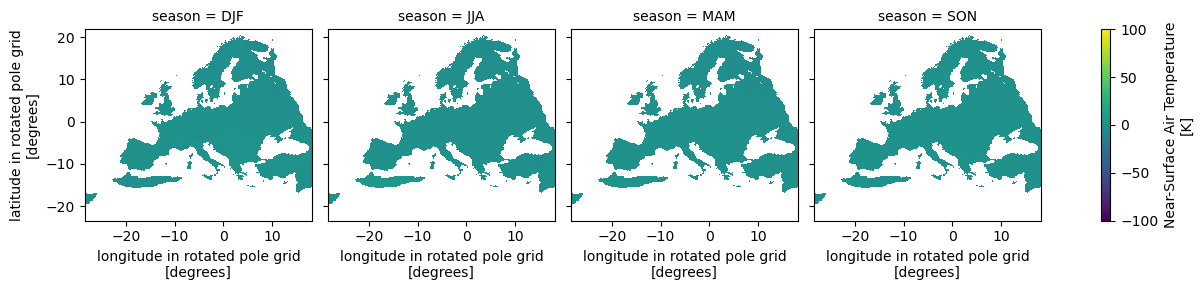

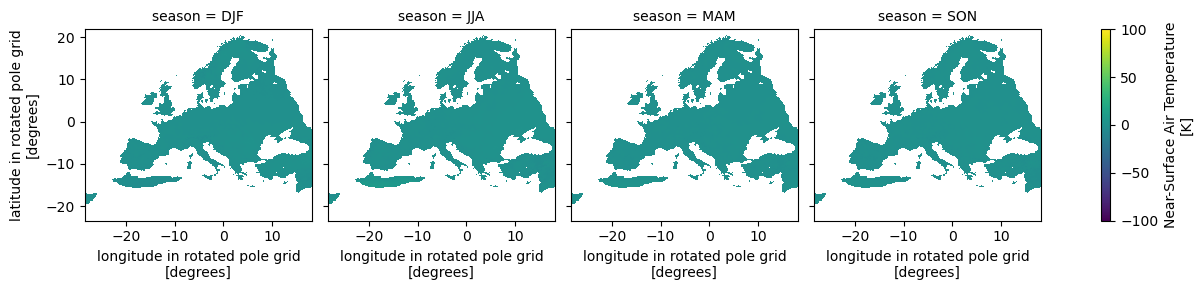

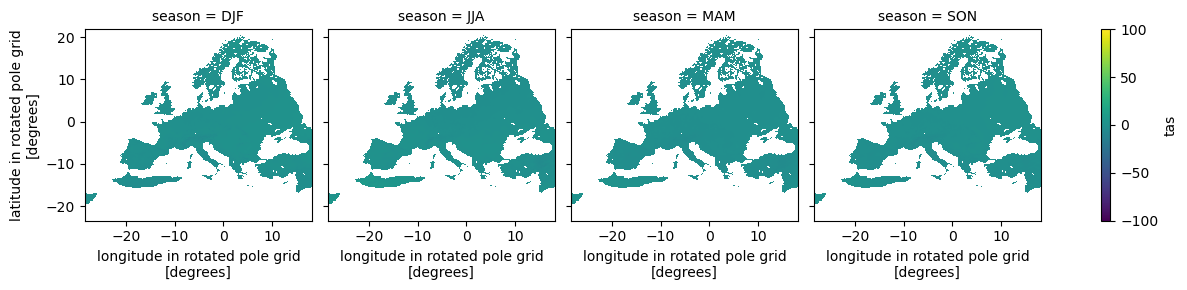

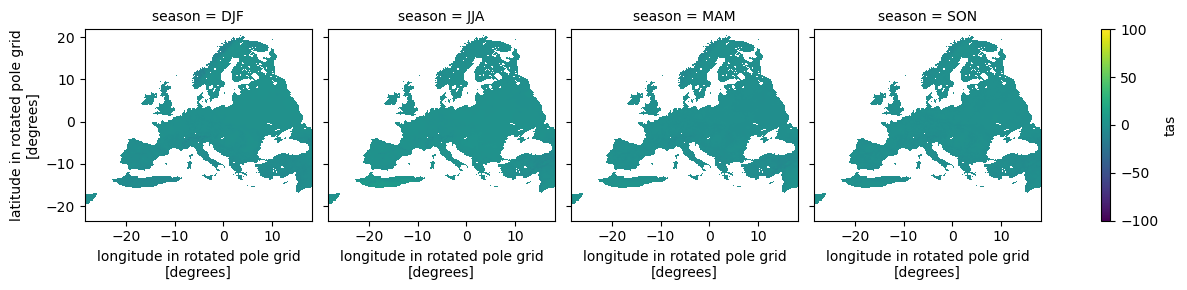

In [26]:
for mip_era, driving_source_id in CMIP_dic.items():
    for period in periods:
        if driving_source_id == 'ERA5':
            dsets = open_datasets(
                [variable],
                frequency=frequency,
                driving_source_id=driving_source_id,
                driving_variant_label =  'r1i1p1f1',
                mask=True,
                add_missing_bounds=False,
                rewrite_grid=True,
            )
        else:
            dsets = open_datasets(
                [variable],
                frequency=frequency,
                driving_source_id=driving_source_id,
                mask=True,
                add_missing_bounds=False,
                rewrite_grid=True,
            )
        if mip_era == 'CMIP5':
            dsets_day = open_datasets(
                [variable],
                frequency='day',
                source_id = ['WRF381P', 'HIRHAM5', 'RegCM4-6'],
                driving_source_id=driving_source_id,
                mask=True,
                add_missing_bounds=False,
            )
            static_vars = ["orog", "sftlf", "areacella", "mask"]
            ## resample dset_day
            dsets_mon = {}
            for dset in dsets_day.keys():
                dsets_copy = dsets_day[dset].copy()
                ds_var_mon = dsets_copy[[variable]].resample(time="ME").mean()
                for var in static_vars:
                    if var in dsets_copy.variables:
                        ds_var_mon[var] = dsets_copy[var]
                dsets_mon[dset.replace('.day.', '.mon.')] = ds_var_mon
            dsets = dsets | dsets_mon
    
        for dset in dsets.keys():
            if not check_equal_period(dsets[dset], period):
                print(f"Temporal coverage of {dset} does not match with {period}")

        key = "CORDEX-CMIP6.EUR-12.MOHC.ERA5.evaluation.r1i1p1f1.HadREM3-GA7-05.v1-r1.mon.v20260219"
        if key in dsets:
            del dsets[key]

        for dset in dsets.keys():
            dsets[dset] = standardize_unit(dsets[dset], variable)

        dsets = regrid_dsets(dsets, rotated_grid, method=regridding)

        if variable == "tas":
            to_remove = []
        
            for dset_name, ds in dsets.items():
                if "orog" in ds:
                    h_c = height_temperature_correction(ds.orog, ref_on_rotated.elevation)
                    ds["tas"] = ds.tas - h_c.fillna(0)
                else:
                    to_remove.append(dset_name)
            
            for dset_name in to_remove:
                print(dset_name)
                del dsets[dset_name]

        # mask with sftlf
        for dset in dsets.keys():
            dsets[dset][variable] = dsets[dset][variable].where(dsets[dset]["sftlf"] > 0.0)

        ref_seasmean = ref_seasmean_periods[f"{period.start}-{period.stop}"]
        if var_dic[index]["diff"] == "abs":
            diffs = {
                dset_id: seasonal_mean(ds[[variable]].sel(time=period)).compute()
                - ref_seasmean
                for dset_id, ds in dsets.items()
                if variable in ds.variables
            }
        elif var_dic[index]["diff"] == "rel":
            diffs = {
                dset_id: 100
                * (
                    seasonal_mean(ds[[variable]].sel(time=period)).compute()
                    - (ref_seasmean)
                )
                / (ref_seasmean)
                for dset_id, ds in dsets.items()
                if variable in ds.variables
            }

        seasonal_bias = xr.concat(
            list(diffs.values()),
            dim=xr.DataArray(
                list(
                    map(
                        lambda x: short_iid(x, ["source_id", "version_realization"], delimiter="_"),
                        diffs.keys(),
                    )
                ),
                dims="dset_id",
            ),
            compat="override",
            coords="minimal",
        )

        seasonal_bias[variable] = seasonal_bias[variable].where(
            (seasonal_bias[variable] <= 1000) & (seasonal_bias[variable] >= -1000)
        )

        seasonal_bias[variable].isel(dset_id=0).plot(col="season", vmin=-100, vmax=100)

        dset_id_regions = regional_means(
            seasonal_bias, regions, aggr=var_dic[index]["aggr"]
        )
        dset_id_regions.to_netcdf(
            f"{save_results_path}/{index}_{mip_era}_{reference_regions}_{period.start}-{period.stop}.nc"
        )

### Load results for both CMIP5 and CMIP6 simulations

#### Visualize both periods

In [42]:
seasons = ["DJF", "MAM", "JJA", "SON"]

In [43]:
period = periods[0]
dset_id_regions_CMIP6_fp = xr.open_dataset(
    f"{save_results_path}/{index}_CMIP6_{reference_regions}_{period.start}-{period.stop}.nc"
)
dset_id_regions_CMIP5_fp = xr.open_dataset(
    f"{save_results_path}/{index}_CMIP5_{reference_regions}_{period.start}-{period.stop}.nc"
)

period = periods[1]
dset_id_regions_CMIP6_sp = xr.open_dataset(
    f"{save_results_path}/{index}_CMIP6_{reference_regions}_{period.start}-{period.stop}.nc"
)
dset_id_regions_CMIP5_sp = xr.open_dataset(
    f"{save_results_path}/{index}_CMIP5_{reference_regions}_{period.start}-{period.stop}.nc"
)

In [44]:
df_CMIP6_fp = dset_id_regions_CMIP6_fp.to_dataframe().reset_index()
df_CMIP5_fp = dset_id_regions_CMIP5_fp.to_dataframe().reset_index()

df_CMIP6_sp = dset_id_regions_CMIP6_sp.to_dataframe().reset_index()
df_CMIP5_sp = dset_id_regions_CMIP5_sp.to_dataframe().reset_index()

In [45]:
period = periods[0]
df_obs = xr.open_dataset(
    f"{save_results_path}/{index}_obs_{reference_regions}_{period.start}-{period.stop}.nc"
)
df_obs_fp = df_obs.to_dataframe().reset_index()

period = periods[1]
df_obs = xr.open_dataset(
    f"{save_results_path}/{index}_obs_{reference_regions}_{period.start}-{period.stop}.nc"
)
df_obs_sp = df_obs.to_dataframe().reset_index()

In [46]:
print(np.min(df_CMIP5_fp[variable]), np.max(df_CMIP5_fp[variable]))
print(np.min(df_CMIP6_fp[variable]), np.max(df_CMIP6_fp[variable]))

-4.1744206854320005 2.6205645070712538
-2.78790469038662 1.7767942220858832


In [47]:
print(np.min(df_CMIP5_sp[variable]), np.max(df_CMIP5_sp[variable]))
print(np.min(df_CMIP6_sp[variable]), np.max(df_CMIP6_sp[variable]))

-4.612102395800443 2.504683432283415
-2.796763255360846 1.726671882792946


In [48]:
list_model_version = np.array((eur_colors["model"].astype(str) + "_" + eur_colors["model_version"].astype(str)).tolist())

In [49]:
if reference_regions == "PRUDENCE":
    regions = [["EA", "IP", "ME", "SC"], ["AL", "BI", "FR", "MD"]]
if reference_regions == "AR6":
    regions = [["NEU", "WCE", "MED", "EEU"]]

In [50]:
# Create dataframes to hold the biases for the subset of models
# whose parents are weighted by the number of models
df_CMIP6_fp_fair = pd.DataFrame(columns=df_CMIP6_fp.columns)
df_CMIP5_fp_fair = pd.DataFrame(columns=df_CMIP6_fp.columns)
df_CMIP6_sp_fair = pd.DataFrame(columns=df_CMIP6_fp.columns)
df_CMIP5_sp_fair = pd.DataFrame(columns=df_CMIP6_fp.columns)

row_idx = 0  # row counter

for model in np.unique(df_CMIP6_fp["dset_id"]):
    model_name, model_version = model.split("_", 1)

    # Get parent information from eur_colors
    row = eur_colors.loc[
        (eur_colors["model"] == model_name) &
        (eur_colors["model_version"] == model_version)
    ].iloc[0]

    parent = f"{row['parent']}_{row['parent_version']}"

    # Only continue if the parent exists in CMIP5
    if parent not in df_CMIP5_fp["dset_id"].values:
        continue

    for i, region in enumerate([x for sublist in regions for x in sublist]):
        for season in seasons:

            # Helper function to extract the 'tas' value
            def get_value(df, dset_id):
                mask = (
                    (df["dset_id"] == dset_id) &
                    (df["season"] == season) &
                    (df["abbrevs"] == region)
                )
                if not mask.any():
                    return np.nan
                return df.loc[mask, variable].iloc[0]

            tas_6_fp = get_value(df_CMIP6_fp, model)
            tas_6_sp = get_value(df_CMIP6_sp, model)
            tas_5_fp = get_value(df_CMIP5_fp, parent)
            tas_5_sp = get_value(df_CMIP5_sp, parent)

            # If no data at all, skip
            if all(np.isnan(x) for x in [tas_6_fp, tas_6_sp, tas_5_fp, tas_5_sp]):
                continue

            common_fields = {
                "season":  season,
                "region":  i,
                "idd":     index,
                "abbrevs": region,
            }

            # CMIP6 fp
            df_CMIP6_fp_fair.loc[row_idx, :] = {
                **common_fields,
                "dset_id": model,
                variable:     tas_6_fp,
            }

            # CMIP6 sp
            df_CMIP6_sp_fair.loc[row_idx, :] = {
                **common_fields,
                "dset_id": model,
                variable:     tas_6_sp,
            }

            # CMIP5 fp
            df_CMIP5_fp_fair.loc[row_idx, :] = {
                **common_fields,
                "dset_id": parent,
                variable:     tas_5_fp,
            }

            # CMIP5 sp
            df_CMIP5_sp_fair.loc[row_idx, :] = {
                **common_fields,
                "dset_id": parent,
                variable:     tas_5_sp,
            }

            row_idx += 1

In [51]:
np.unique(df_CMIP5_fp_fair['dset_id'])

array(['ALADIN63_v1', 'ALARO-0_v1', 'CCLM4-8-17_v1', 'HadREM3-GA7-05_v1',
       'RACMO22E_v1', 'REMO2015_v1', 'RegCM4-6_v1', 'WRF381P_v1'],
      dtype=object)

In [52]:
np.unique(df_CMIP6_fp_fair['dset_id'])

array(['ALARO1-SFX_v1-r1', 'CCLM6-0-1_v1-r1', 'CNRM-ALADIN64E1_v1-r1',
       'HCLIM43-ALADIN_v1-r1', 'HadREM3-GA7-05_v1-r1', 'RACMO23E_v1-r1',
       'REMO2020-2-2_v1-r1', 'RegCM5-0_v1-r1', 'WRF451Q_v1-r1',
       'WRF451Q_v1-r2'], dtype=object)

['EA', 'IP', 'ME', 'SC']


/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/joint-evaluation/eval-book/tools.py:803: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CMIP6_region_fp["season_num"] = df_CMIP6_region_fp["season"].apply(
/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/joint-evaluation/eval-book/tools.py:806: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CMIP6_region_sp["season_num"] = df_CMIP6_region_sp["season"].apply(
/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/joint-evaluation/eval-book/tools.py:810: SettingWithCopyWarning: 
A

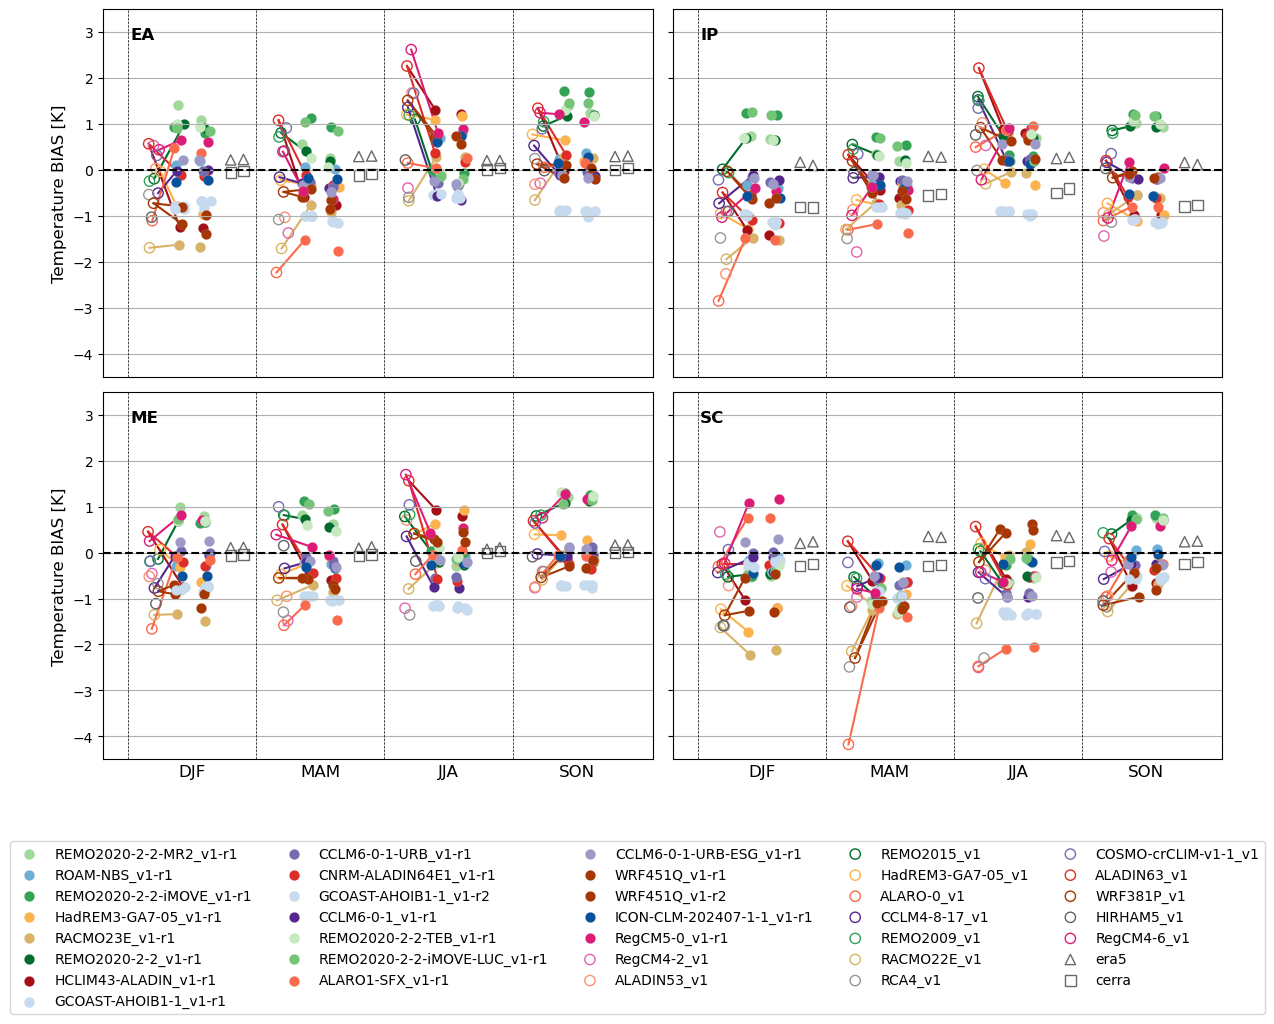

['AL', 'BI', 'FR', 'MD']


/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/joint-evaluation/eval-book/tools.py:803: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CMIP6_region_fp["season_num"] = df_CMIP6_region_fp["season"].apply(
/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/joint-evaluation/eval-book/tools.py:806: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CMIP6_region_sp["season_num"] = df_CMIP6_region_sp["season"].apply(
/mnt/CORDEX_CMIP6_tmp/user_tmp/jdiezsierra/joint-evaluation/eval-book/tools.py:810: SettingWithCopyWarning: 
A

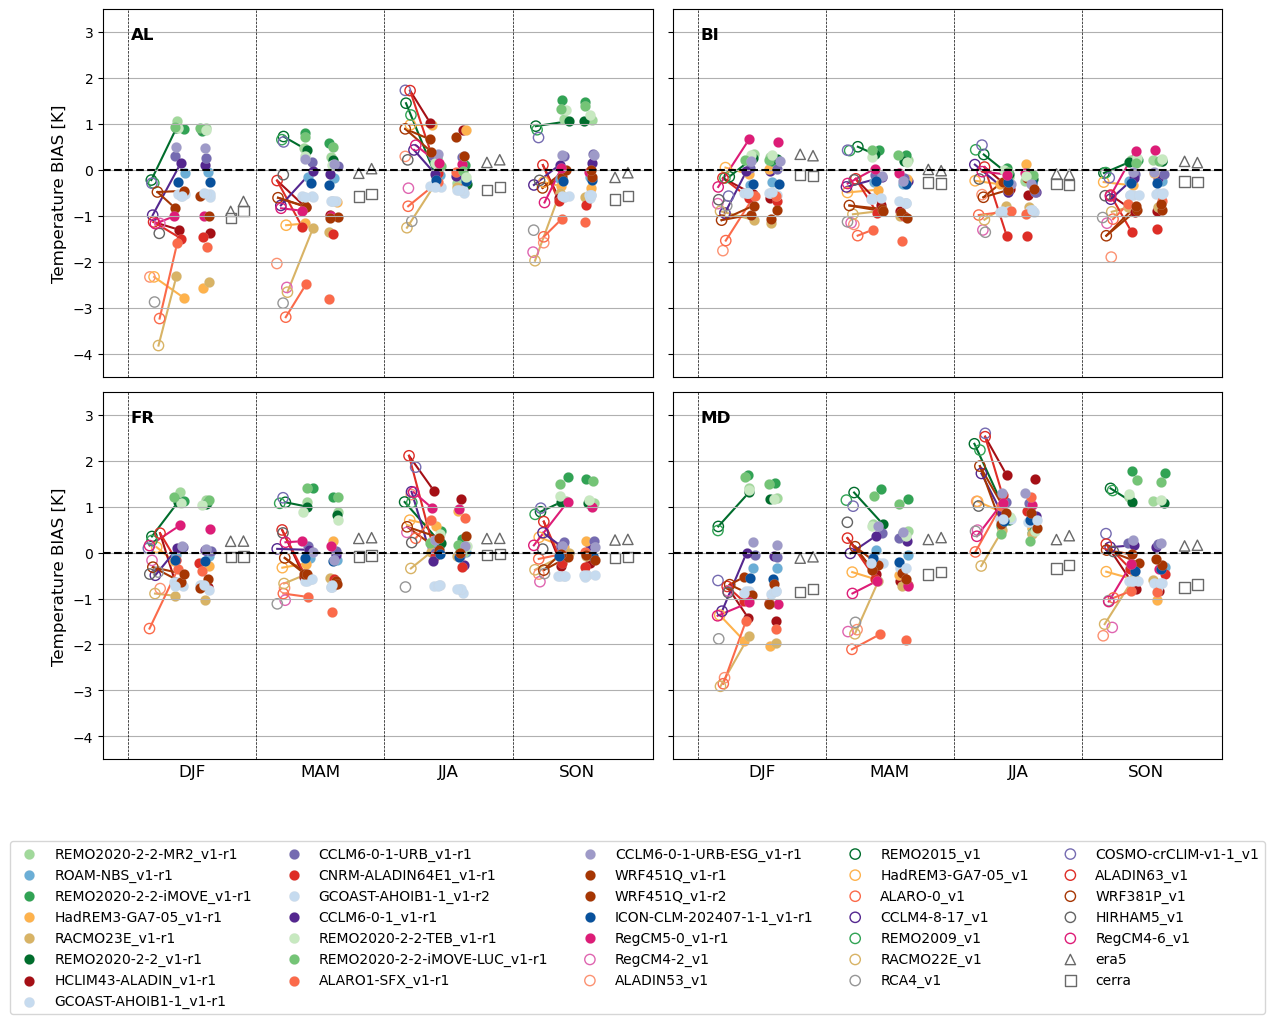

In [38]:
for n_r, regs in enumerate(regions):
    kwargs = {
        "regs": regs,
        "nregs": "A" if n_r == 0 else "B",
        "seasons": seasons,
        "variable": variable,
        "index": index,
        "eur_colors": eur_colors,
        "list_model_version": list_model_version,
        "df_CMIP6_fp": df_CMIP6_fp,
        "df_CMIP6_sp": df_CMIP6_sp,
        "df_CMIP5_fp": df_CMIP5_fp,
        "df_CMIP5_sp": df_CMIP5_sp,
        "df_obs_fp": df_obs_fp,
        "df_obs_sp": df_obs_sp,
        "df_CMIP6_fp_fair": df_CMIP6_fp_fair,
        "df_CMIP6_sp_fair": df_CMIP6_sp_fair,
        "df_CMIP5_fp_fair": df_CMIP5_fp_fair,
        "df_CMIP5_sp_fair": df_CMIP5_sp_fair,
        "save_figure_path": save_figure_path,
        "reference_regions": reference_regions
    }
    fig_bias, ax_bias = plot_regional_biases(**kwargs)

In [39]:
seasons = ['DJF', 'MAM', 'JJA', 'SON']
model_types = ['CMIP5', 'CMIP6']
columns = pd.MultiIndex.from_product([seasons, model_types], names=['Season', 'Project'])
rows = [x for sublist in regions for x in sublist]

df = pd.DataFrame(np.nan, index=rows, columns=columns)

print(df)

Season    DJF         MAM         JJA         SON      
Project CMIP5 CMIP6 CMIP5 CMIP6 CMIP5 CMIP6 CMIP5 CMIP6
EA        NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
IP        NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
ME        NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
SC        NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
AL        NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
BI        NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
FR        NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
MD        NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN


In [53]:
def weighted_stats(df_sr, variable):
    df_sr['model_base'] = df_sr['dset_id'].str.split('_').str[0]
    model_counts = df_sr.groupby('model_base')[variable].transform('count')
    df_sr['weight'] = 1 / model_counts
    abs_vals = abs(df_sr[variable])
    mean_w = np.average(abs_vals, weights=df_sr['weight'])
    vals = df_sr[variable]
    std_w = np.sqrt(np.sum(df_sr['weight'] * (vals - np.average(vals, weights=df_sr['weight']))**2) / np.sum(df_sr['weight']))
    return mean_w, std_w

In [41]:
for season in seasons:
    for region in [x for sublist in regions for x in sublist]:
        CMIP5_sr = df_CMIP5_fp_fair[
        (df_CMIP5_fp_fair['season'] == season) &
        (df_CMIP5_fp_fair['abbrevs'] == region)].drop_duplicates(subset='dset_id', keep='first')

        CMIP6_sr = df_CMIP6_fp_fair[
        (df_CMIP6_fp_fair['season'] == season) &
        (df_CMIP6_fp_fair['abbrevs'] == region)].drop_duplicates(subset='dset_id', keep='first')

        weighted_mean_CMIP6, weighted_std_CMIP6 = weighted_stats(CMIP6_sr, variable)
        weighted_mean_CMIP5, weighted_std_CMIP5 = weighted_stats(CMIP5_sr, variable)
        
        #df.loc[region, (season, "CMIP5")] = f"{abs(CMIP5_sr[variable]).mean().round(2)}({CMIP5_sr[variable].std().round(2)})"
        df.loc[region, (season, "CMIP5")] = f"{weighted_mean_CMIP5.round(2)}({weighted_std_CMIP5.round(2)})"
        df.loc[region, (season, "CMIP6")] = f"{weighted_mean_CMIP6.round(2)}({weighted_std_CMIP6.round(2)})"

/tmp/ipykernel_657392/3404379436.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.66(0.72)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[region, (season, "CMIP5")] = f"{weighted_mean_CMIP5.round(2)}({weighted_std_CMIP5.round(2)})"
/tmp/ipykernel_657392/3404379436.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.77(0.86)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[region, (season, "CMIP6")] = f"{weighted_mean_CMIP6.round(2)}({weighted_std_CMIP6.round(2)})"
/tmp/ipykernel_657392/3404379436.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.89(1.08)' has dtype incompatible with float64, please explicitly cast to a compatib

In [31]:
df.to_csv(f"{reference_regions}_{index}_{periods[0].start}-{periods[0].stop}_summary_results.csv")

In [32]:
if len(CMIP5_sr) != 8:
    print("Problems with CMIP5")
if len(CMIP6_sr) != 10:
    print("Problems with CMIP6")